In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ford_car_dataset.xlsx to ford_car_dataset.xlsx


In [3]:
df = pd.read_excel("ford_car_dataset.xlsx")

In [4]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [5]:
missing_values = df.isnull().sum()

In [6]:
missing_percentage = (missing_values / len(df)) * 100


In [7]:
missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

print(missing_df)

              Missing Values  Percentage (%)
model                      0             0.0
year                       0             0.0
price                      0             0.0
transmission               0             0.0
mileage                    0             0.0
fuelType                   0             0.0
tax                        0             0.0
mpg                        0             0.0
engineSize                 0             0.0


In [8]:
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)

In [9]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_589/3448830320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [10]:
# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates removed
print("Duplicate Rows after removal:", df.duplicated().sum())


Duplicate Rows: 154
Duplicate Rows after removal: 0


In [11]:
import pandas as pd

# Load dataset
df = pd.read_excel("ford_car_dataset.xlsx")

# Statistical summary
print(df.describe())

# Target variable: price
print("\nTarget Variable Statistics (Price)")
print("Minimum Price :", df["price"].min())
print("Maximum Price :", df["price"].max())
print("Mean Price    :", df["price"].mean())
print("Median Price  :", df["price"].median())

               year         price        mileage           tax           mpg  \
count  17966.000000  17966.000000   17966.000000  17966.000000  17966.000000   
mean    2016.866470  12279.534844   23362.608761    113.329456     57.906980   
std        2.050336   4741.343657   19472.054349     62.012456     10.125696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000    9987.000000     30.000000     52.300000   
50%     2017.000000  11291.000000   18242.500000    145.000000     58.900000   
75%     2018.000000  15299.000000   31060.000000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17966.000000  
mean       1.350807  
std        0.432367  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

Target Variable Statistics (Price)
Minimum Price : 495
Maximum Price : 54995
Mea

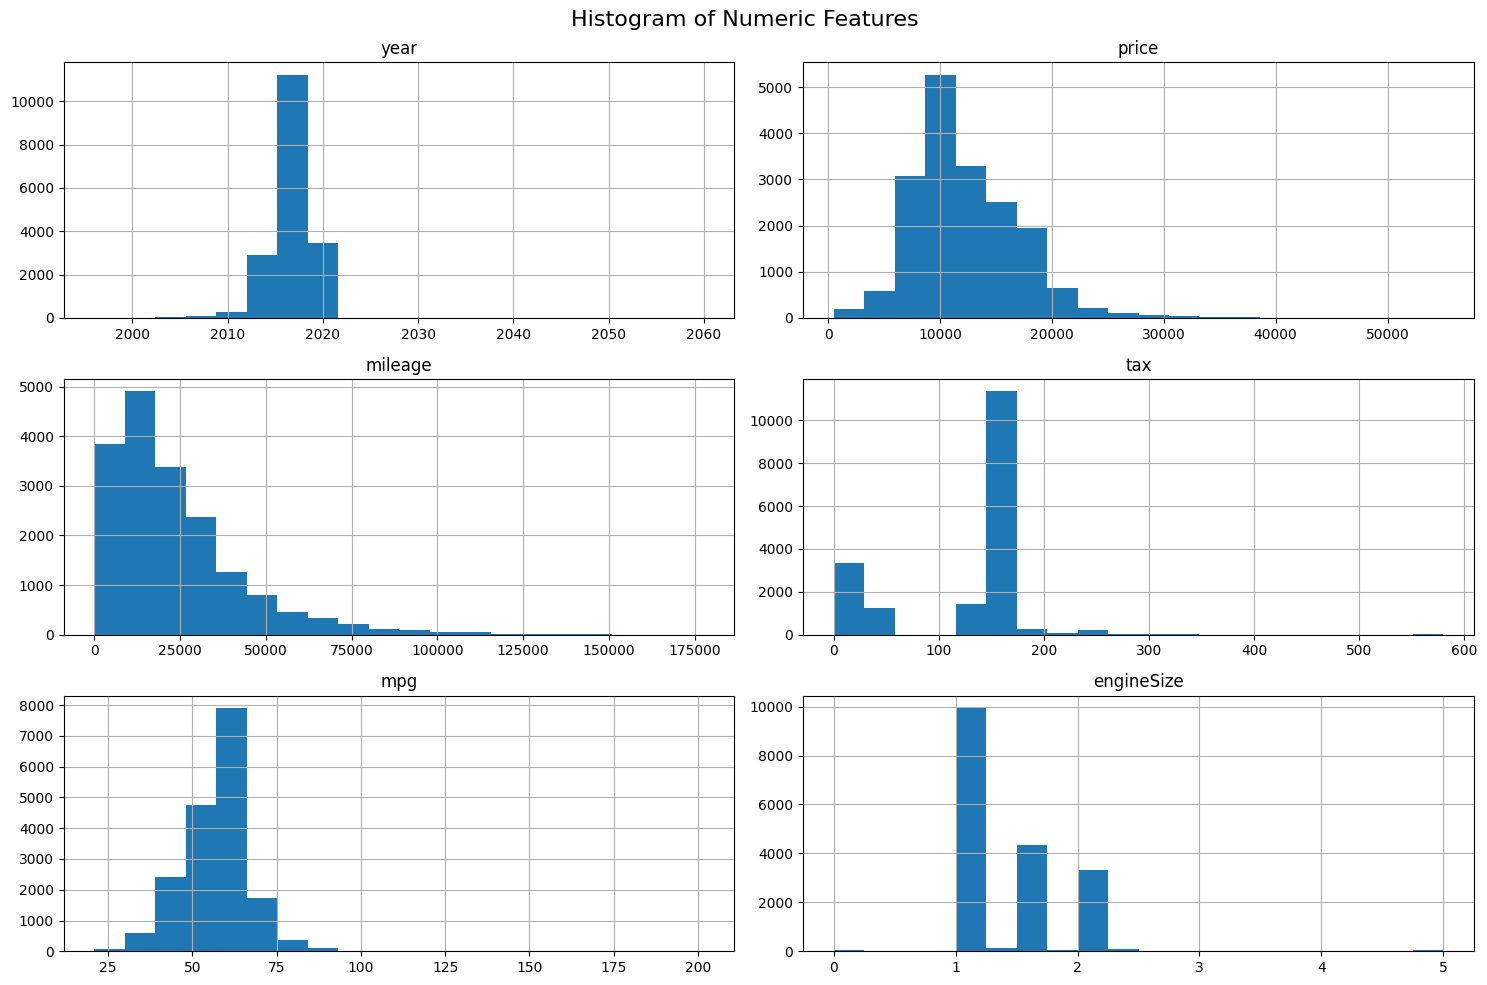

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("ford_car_dataset.xlsx")


numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_columns].hist(figsize=(15, 10), bins=20)

plt.suptitle("Histogram of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

Categorical Columns:
Index(['model', 'transmission', 'fuelType'], dtype='object')


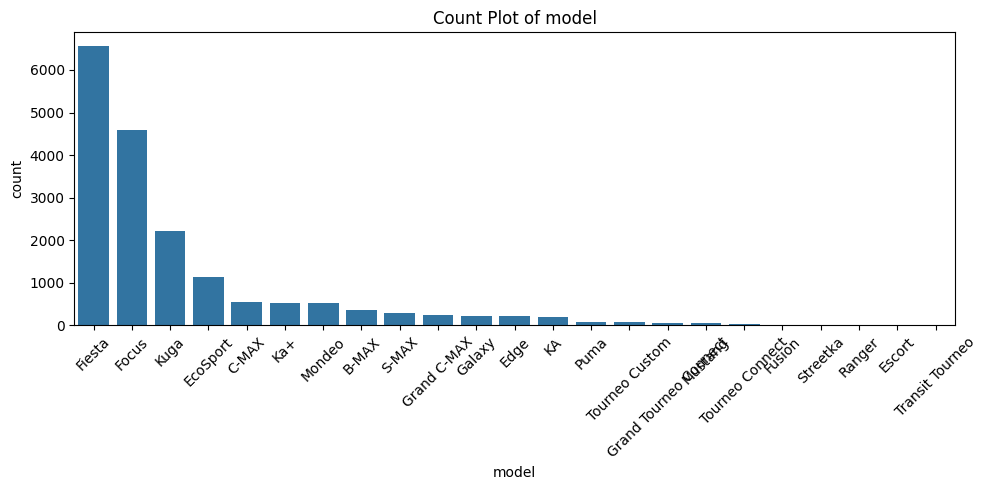

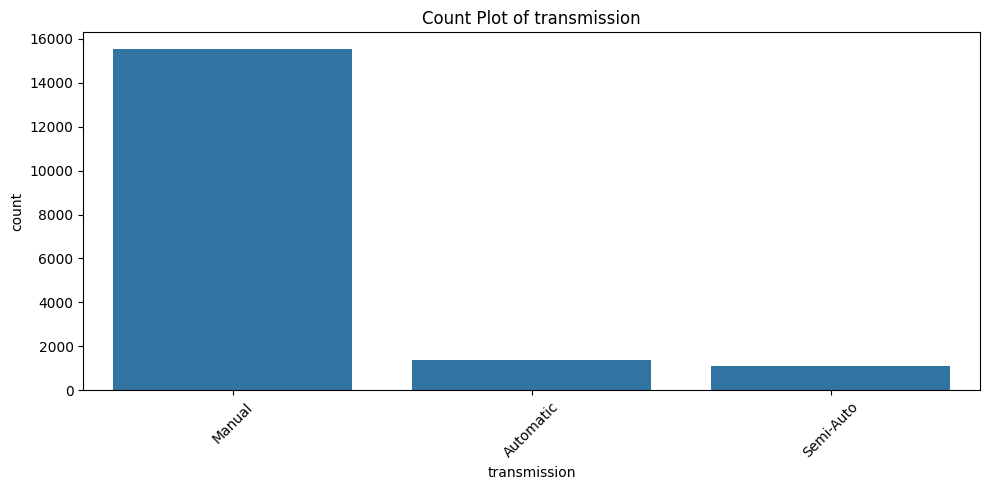

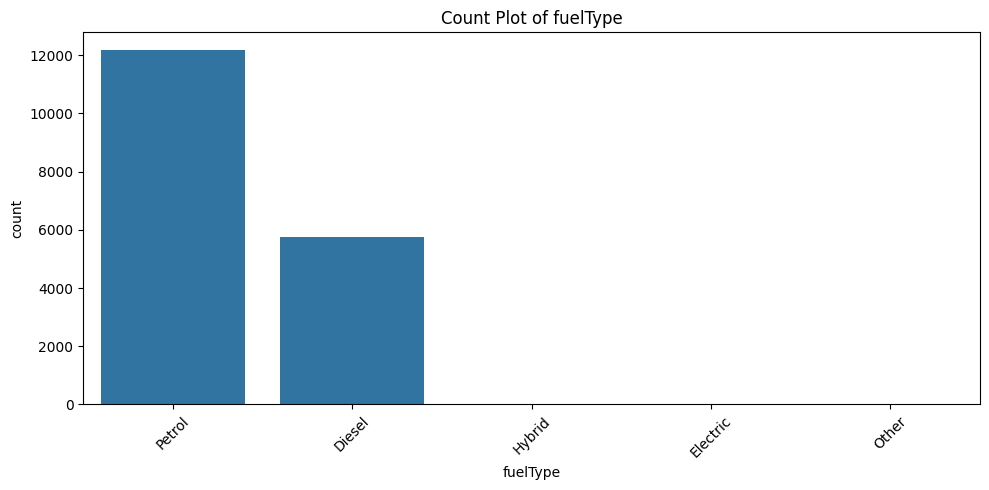

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(cat_cols)

# Create count plots
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

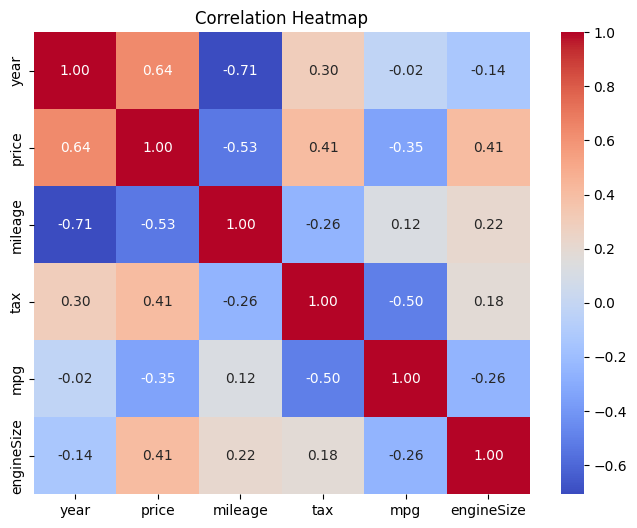


Correlation with Price:
price         1.000000
year          0.636009
engineSize    0.411178
tax           0.406857
mpg          -0.346419
mileage      -0.530659
Name: price, dtype: float64


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# Correlation with target variable (price)
print("\nCorrelation with Price:")
print(corr["price"].sort_values(ascending=False))

In [16]:


# Independent Features (X)
X = df.drop("price", axis=1)

# Dependent Feature (y)
y = df["price"]

print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (y):")
print(y.name)

Independent Features (X):
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

Dependent Feature (y):
price


In [17]:

# Show original categorical columns (before encoding)
print("Before Encoding:")
print(df[['model', 'transmission']].head())

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType'], drop_first=True)

# Show encoded columns (after encoding)
print("\nAfter Encoding:")
print(df_encoded.head())

# Display new column names
print("\nEncoded Columns:")
print(df_encoded.columns)

Before Encoding:
    model transmission
0  Fiesta    Automatic
1   Focus       Manual
2   Focus       Manual
3  Fiesta       Manual
4  Fiesta    Automatic

After Encoding:
   year  price  mileage  tax   mpg  engineSize  model_C-MAX  model_EcoSport  \
0  2017  12000    15944  150  57.7         1.0        False           False   
1  2018  14000     9083  150  57.7         1.0        False           False   
2  2017  13000    12456  150  57.7         1.0        False           False   
3  2019  17500    10460  145  40.3         1.5        False           False   
4  2019  16500     1482  145  48.7         1.0        False           False   

   model_Edge  model_Escort  ...  model_Streetka  model_Tourneo Connect  \
0       False         False  ...           False                  False   
1       False         False  ...           False                  False   
2       False         False  ...           False                  False   
3       False         False  ...           False     

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding
df = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType'], drop_first=True)

# Independent features (X)
X = df.drop("price", axis=1)

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print(X_scaled.head())

       year   mileage       tax       mpg  engineSize  model_C-MAX  \
0  0.065128 -0.380998  0.591358 -0.020442   -0.811386    -0.176538   
1  0.552866 -0.733359  0.591358 -0.020442   -0.811386    -0.176538   
2  0.065128 -0.560132  0.591358 -0.020442   -0.811386    -0.176538   
3  1.040605 -0.662640  0.510727 -1.738890    0.345070    -0.176538   
4  1.040605 -1.123724  0.510727 -0.909294   -0.811386    -0.176538   

   model_EcoSport  model_Edge  model_Escort  model_Fiesta  ...  \
0       -0.260658   -0.108227     -0.007461      1.319080  ...   
1       -0.260658   -0.108227     -0.007461     -0.758104  ...   
2       -0.260658   -0.108227     -0.007461     -0.758104  ...   
3       -0.260658   -0.108227     -0.007461      1.319080  ...   
4       -0.260658   -0.108227     -0.007461      1.319080  ...   

   model_Streetka  model_Tourneo Connect  model_Tourneo Custom  \
0       -0.010551              -0.042897             -0.062092   
1       -0.010551              -0.042897          